<a href="https://colab.research.google.com/github/Miranics/ML_Multimodal-User-Auth-System/blob/main/multimodal_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Multimodal User Authentication and Product Recommendation



## Notebook Introduction

This notebook demonstrates the complete multimodal workflow for secure product recommendation. It covers data quality checks, exploratory analysis, image and audio preprocessing, feature extraction, model training, evaluation, and system simulation.

What this notebook will do:
- Validate and merge tabular datasets.
- Visualize distributions, outliers, and correlations.
- Process facial images and voice recordings with augmentation.
- Train and evaluate face, voice, and recommendation models.
- Demonstrate both authorized and unauthorized transaction flows.

Expected outputs include engineered datasets, trained model artifacts, evaluation metrics, and visual evidence for report submission.

## 1) Install Dependencies

In [25]:
!pip -q install numpy pandas scikit-learn joblib opencv-python scikit-image librosa soundfile matplotlib seaborn scipy

## 2) Clone Repository and Set Working Directory

In [26]:
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/Miranics/ML_Multimodal-User-Auth-System.git"
REPO_DIR = Path("/content/ML_Multimodal-User-Auth-System")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

%cd /content/ML_Multimodal-User-Auth-System
print("Working directory:", Path.cwd())

/content/ML_Multimodal-User-Auth-System
Working directory: /content/ML_Multimodal-User-Auth-System


## 3) Import Libraries and Configure Paths

In [27]:
import json
import sys
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path

ROOT = Path.cwd()
RAW = ROOT / "data" / "raw"
IMAGES = ROOT / "data" / "images"
AUDIO = ROOT / "data" / "audio"
PROCESSED = ROOT / "data" / "processed"
REPORTS = ROOT / "reports"

for p in [PROCESSED, REPORTS]:
    p.mkdir(parents=True, exist_ok=True)

print("Paths ready.")

Paths ready.


## 4) Verify Input Files

In [28]:
required = [
    RAW / "customer_social_profiles.csv",
    RAW / "customer_transactions.csv"
]

for f in required:
    print(f, "exists:", f.exists())

print("Image folders:", [p.name for p in IMAGES.iterdir() if p.is_dir()])
print("Audio folders:", [p.name for p in AUDIO.iterdir() if p.is_dir()])

/content/ML_Multimodal-User-Auth-System/data/raw/customer_social_profiles.csv exists: True
/content/ML_Multimodal-User-Auth-System/data/raw/customer_transactions.csv exists: True
Image folders: ['member_1', 'unauthorized', 'member_3', 'member_2']
Audio folders: ['member_1', 'unauthorized', 'member_3', 'member_2']


## 5) Load Raw Tabular Data

In [29]:
social = pd.read_csv(RAW / "customer_social_profiles.csv")
tx = pd.read_csv(RAW / "customer_transactions.csv")

print("Social shape:", social.shape)
print("Transactions shape:", tx.shape)
display(social.head())
display(tx.head())

Social shape: (155, 5)
Transactions shape: (150, 6)


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


## 6) Data Cleaning and Merge Validation

In [30]:
def quality_report(df, name):
    print()
    print(name)
    print("duplicates:", int(df.duplicated().sum()))
    print("null counts:")
    print(df.isnull().sum())
    print("dtypes:")
    print(df.dtypes)

quality_report(social, "Social Profiles")
quality_report(tx, "Transactions")


Social Profiles
duplicates: 5
null counts:
customer_id_new            0
social_media_platform      0
engagement_score           0
purchase_interest_score    0
review_sentiment           0
dtype: int64
dtypes:
customer_id_new             object
social_media_platform       object
engagement_score             int64
purchase_interest_score    float64
review_sentiment            object
dtype: object

Transactions
duplicates: 0
null counts:
customer_id_legacy     0
transaction_id         0
purchase_amount        0
purchase_date          0
product_category       0
customer_rating       10
dtype: int64
dtypes:
customer_id_legacy      int64
transaction_id          int64
purchase_amount         int64
purchase_date          object
product_category       object
customer_rating       float64
dtype: object


## 7) EDA Summary and Plots

This section combines statistical profiling with visual diagnostics to support data quality interpretation before model training. The plots below show distribution behavior, outlier structure, class balance, platform variation, and temporal trends.

,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
count,155,155,155.000000,155.000000,155
unique,84,5,NaN,NaN,3
top,A155,Twitter,NaN,NaN,Positive
freq,7,38,NaN,NaN,63
mean,NaN,NaN,75.606452,3.152903,NaN
std,NaN,NaN,14.568021,1.142867,NaN
min,NaN,NaN,50.000000,1.000000,NaN
25%,NaN,NaN,63.500000,2.350000,NaN
50%,NaN,NaN,77.000000,3.200000,NaN
75%,NaN,NaN,87.500000,4.100000,NaN


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
count,150.000000,150.000000,150.000000,150,150,140.00000
unique,NaN,NaN,NaN,150,5,NaN
top,NaN,NaN,NaN,2024-01-01,Sports,NaN
freq,NaN,NaN,NaN,1,35,NaN
mean,148.760000,1075.500000,280.780000,NaN,NaN,2.98500
std,30.046425,43.445368,121.329595,NaN,NaN,1.20699
min,100.000000,1001.000000,51.000000,NaN,NaN,1.00000
25%,121.250000,1038.250000,179.000000,NaN,NaN,1.95000
50%,150.500000,1075.500000,274.000000,NaN,NaN,3.00000
75%,174.750000,1112.750000,388.500000,NaN,NaN,4.00000


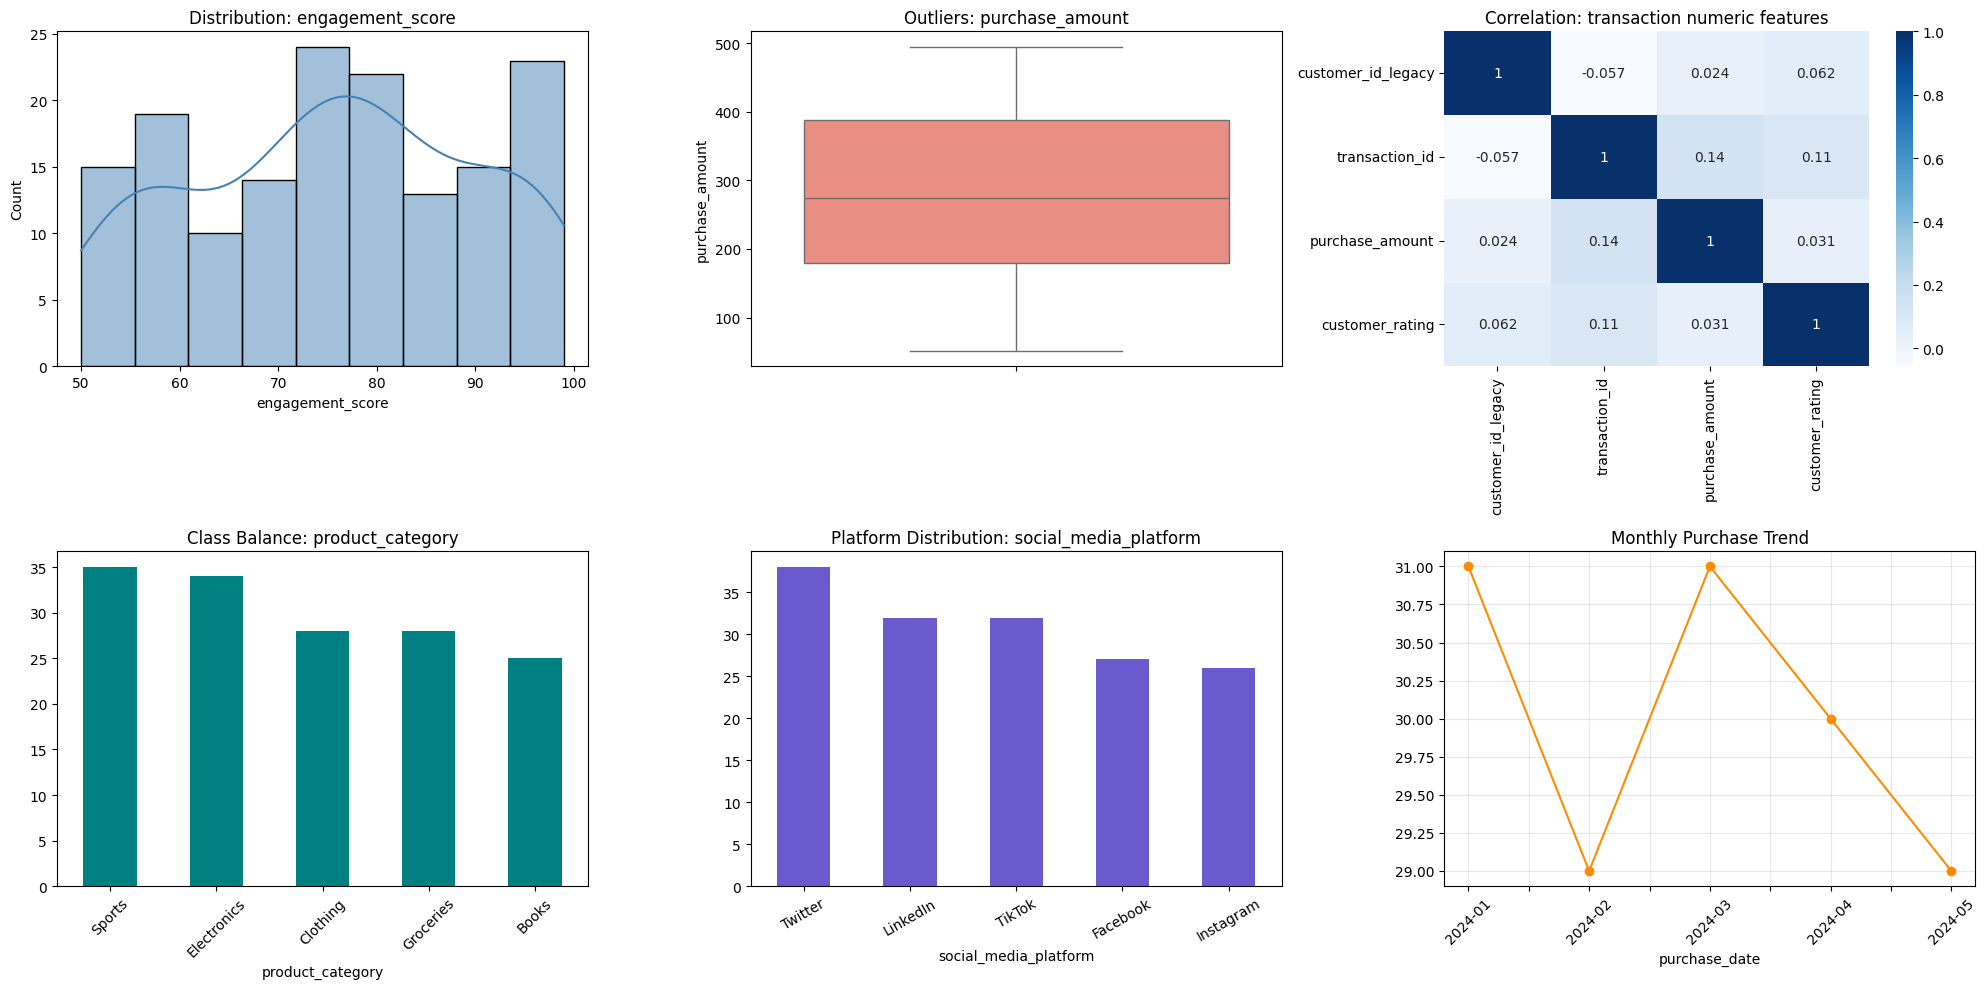

Interpretation: The EDA suggests class imbalance in product categories, visible purchase amount outliers, and varying customer behavior by platform and time.


In [31]:
display(social.describe(include="all"))
display(tx.describe(include="all"))

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

#  Engagement distribution
sns.histplot(social["engagement_score"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution: engagement_score")

#  Purchase amount outliers
sns.boxplot(y=tx["purchase_amount"], ax=axes[1], color="salmon")
axes[1].set_title("Outliers: purchase_amount")

#  Numeric correlation
num_tx = tx.select_dtypes(include=[np.number])
sns.heatmap(num_tx.corr(numeric_only=True), annot=True, cmap="Blues", ax=axes[2])
axes[2].set_title("Correlation: transaction numeric features")

#  Product class distribution (if available)
prod_col = next((c for c in tx.columns if c.lower() in ["product", "product_name", "purchased_product", "item", "target", "product_category"]), None)
if prod_col:
    tx[prod_col].astype(str).value_counts().head(12).plot(kind="bar", ax=axes[3], color="teal")
    axes[3].set_title(f"Class Balance: {prod_col}")
    axes[3].tick_params(axis="x", rotation=45)
else:
    axes[3].text(0.5, 0.5, "No product target column found", ha="center", va="center")
    axes[3].set_axis_off()

#  Social platform distribution (if available)
platform_col = next((c for c in social.columns if "platform" in c.lower()), None)
if platform_col:
    social[platform_col].astype(str).value_counts().plot(kind="bar", ax=axes[4], color="slateblue")
    axes[4].set_title(f"Platform Distribution: {platform_col}")
    axes[4].tick_params(axis="x", rotation=30)
else:
    axes[4].text(0.5, 0.5, "No platform column found", ha="center", va="center")
    axes[4].set_axis_off()

#  Purchase date trend (if available)
if "purchase_date" in tx.columns:
    dt = pd.to_datetime(tx["purchase_date"], errors="coerce")
    monthly = dt.dt.to_period("M").astype(str).value_counts().sort_index()
    monthly.plot(marker="o", ax=axes[5], color="darkorange")
    axes[5].set_title("Monthly Purchase Trend")
    axes[5].tick_params(axis="x", rotation=45)
    axes[5].grid(alpha=0.3)
else:
    axes[5].text(0.5, 0.5, "No purchase_date column found", ha="center", va="center")
    axes[5].set_axis_off()

plt.tight_layout()
plt.show()

print("Interpretation: The EDA suggests class imbalance in product categories, visible purchase amount outliers, and varying customer behavior by platform and time.")

## 8) Run Data Merge

In [32]:
subprocess.run([sys.executable, "-m", "src.data_merge"], check=True)
merged = pd.read_csv(PROCESSED / "merged_features.csv")
print("Merged shape:", merged.shape)
display(merged.head())

Merged shape: (219, 16)


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment,member_id,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating,purchase_date_year,purchase_date_month,purchase_date_day,purchase_date_dow
0,A190,Twitter,82,4.8,Neutral,190,190,1031,333,2024-01-31,Groceries,3.8,2024,1,31,2
1,A190,Twitter,82,4.8,Neutral,190,190,1140,401,2024-05-19,Sports,4.9,2024,5,19,6
2,A150,Facebook,96,1.6,Positive,150,150,1042,389,2024-02-11,Sports,3.2,2024,2,11,6
3,A150,Facebook,96,1.6,Positive,150,150,1046,177,2024-02-15,Books,3.6,2024,2,15,3
4,A162,Twitter,89,2.6,Positive,162,162,1079,101,2024-03-19,Books,4.2,2024,3,19,1


## 9) Image Samples, Augmentations, and Visual Evidence

This section presents richer image evidence by showing multiple member samples and augmentation views. The goal is to clearly demonstrate data diversity and preprocessing quality before feature extraction.

Total images: 10


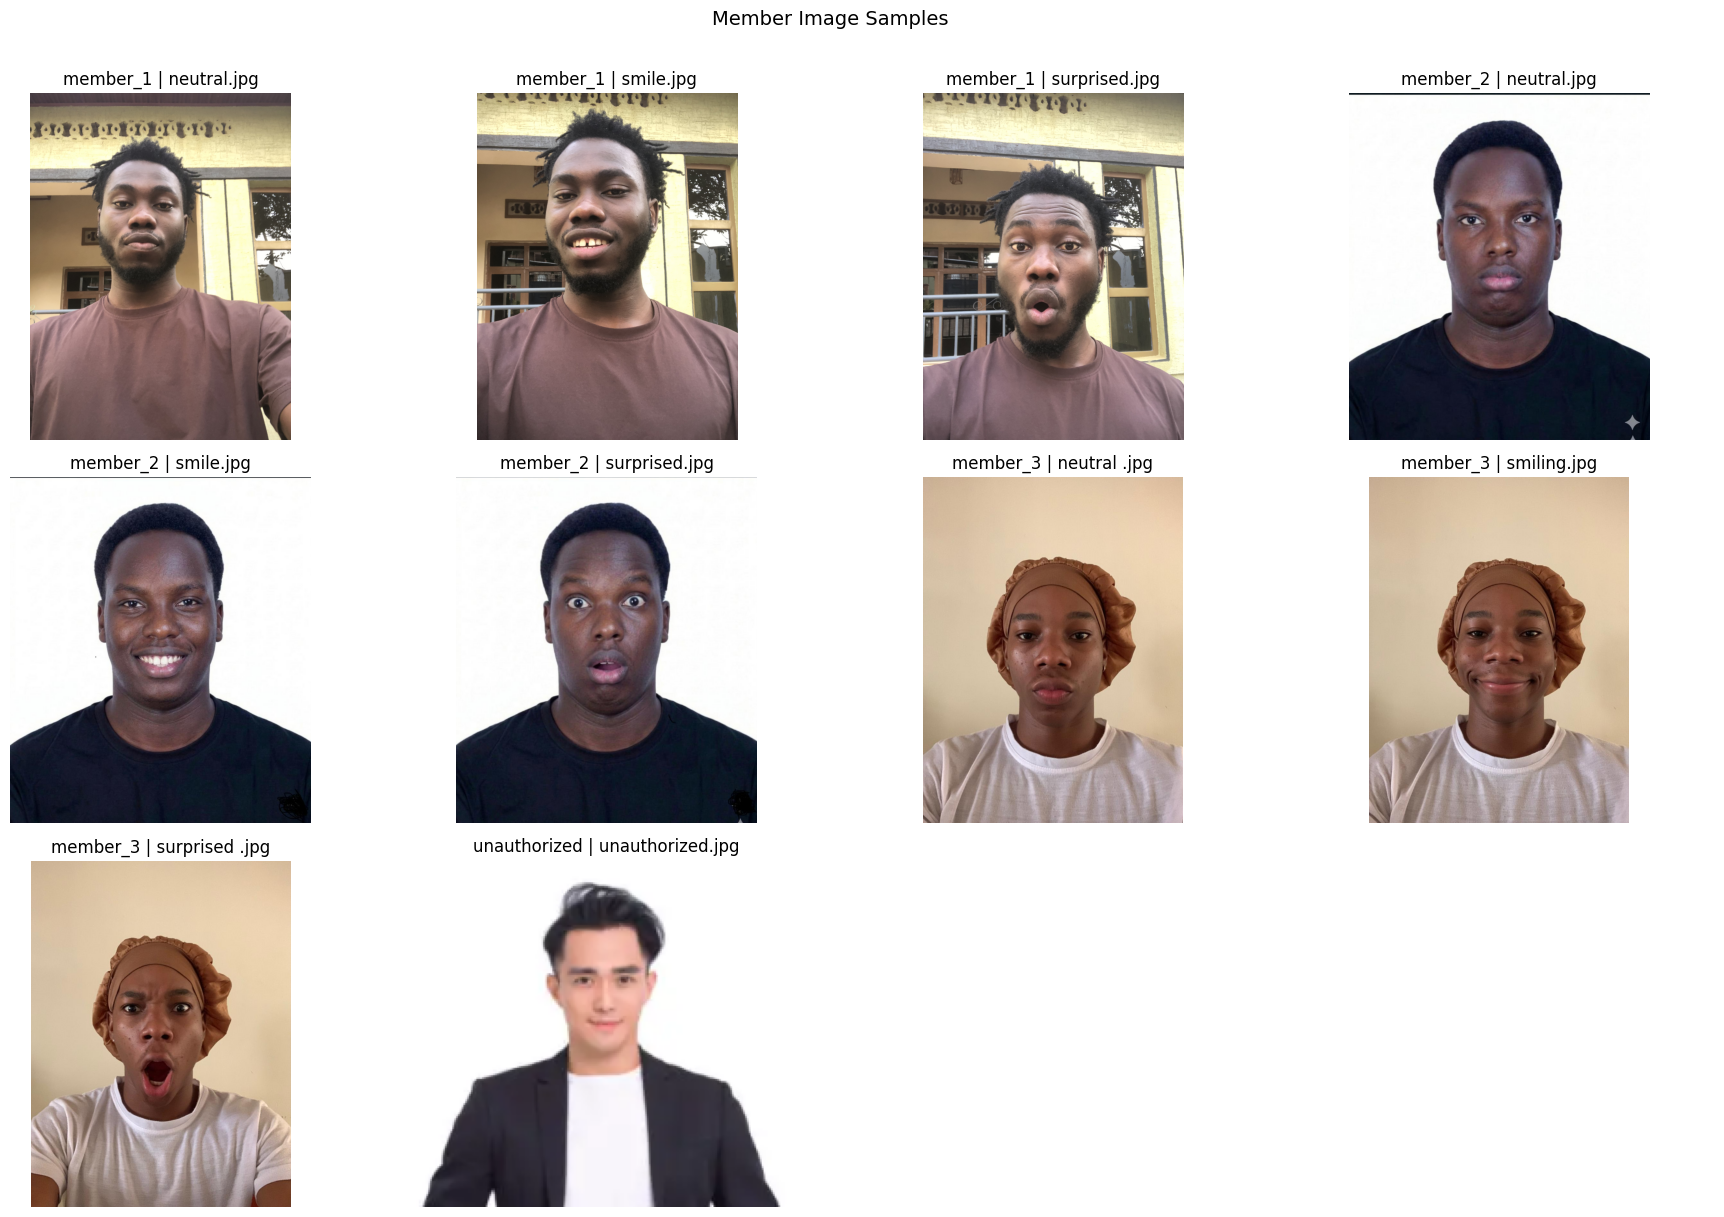

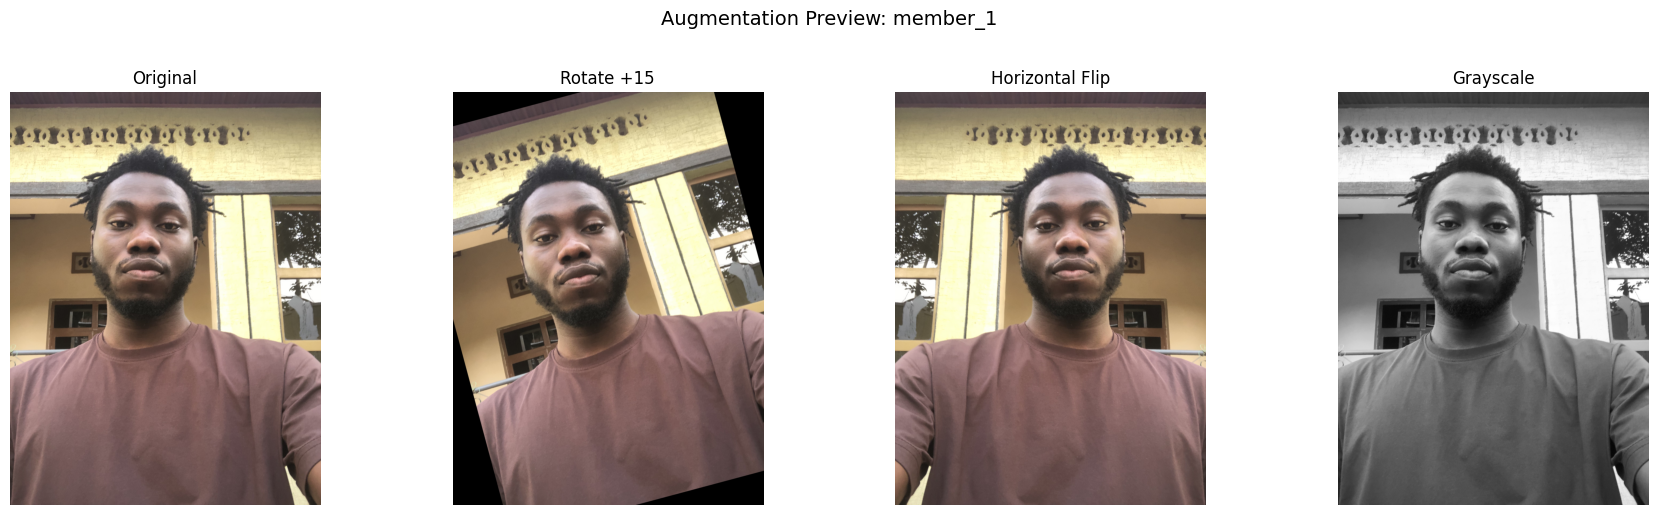

Interpretation: The image panel confirms identity diversity across members, while augmentations increase robustness for face model training.


In [33]:
image_paths = sorted([p for p in IMAGES.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
print("Total images:", len(image_paths))


if image_paths:
    to_show = image_paths[:12]
    cols = 4
    rows = int(np.ceil(len(to_show) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for i, ax in enumerate(axes.flatten()):
        if i < len(to_show):
            p = to_show[i]
            img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(f"{p.parent.name} | {p.name}")
            ax.axis("off")
        else:
            ax.axis("off")

    plt.suptitle("Member Image Samples", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()


if image_paths:
    sample = image_paths[0]
    img_bgr = cv2.imread(str(sample))
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    rot = cv2.warpAffine(
        img_bgr,
        cv2.getRotationMatrix2D((img_bgr.shape[1] // 2, img_bgr.shape[0] // 2), 15, 1.0),
        (img_bgr.shape[1], img_bgr.shape[0]),
    )
    flip = cv2.flip(img_bgr, 1)

    variants = [
        ("Original", cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), None),
        ("Rotate +15", cv2.cvtColor(rot, cv2.COLOR_BGR2RGB), None),
        ("Horizontal Flip", cv2.cvtColor(flip, cv2.COLOR_BGR2RGB), None),
        ("Grayscale", gray, "gray"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    for ax, (title, im, cmap) in zip(axes, variants):
        ax.imshow(im, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    plt.suptitle(f"Augmentation Preview: {sample.parent.name}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

print("Interpretation: The image panel confirms identity diversity across members, while augmentations increase robustness for face model training.")

## 10) Run Image Feature Extraction

In [34]:
subprocess.run([sys.executable, "-m", "src.image_pipeline"], check=True)
img_features = pd.read_csv(PROCESSED / "image_features.csv")
print("image_features.csv shape:", img_features.shape)
display(img_features.head())

image_features.csv shape: (40, 8199)


,member_id,source_path,augmentation,img_f_0,img_f_1,img_f_2,img_f_3,img_f_4,img_f_5,img_f_6,...,img_f_8186,img_f_8187,img_f_8188,img_f_8189,img_f_8190,img_f_8191,img_f_8192,img_f_8193,img_f_8194,img_f_8195
0,member_1,/content/ML_Multimodal-User-Auth-System/data/i...,original,6.979186e-07,0.001337,0.016595,0.017774,0.026385,0.046157,0.049892,...,0.022930,0.313118,0.298367,0.145583,0.056987,0.092916,0.004980,0.000000,0.172104,0.313118
1,member_1,/content/ML_Multimodal-User-Auth-System/data/i...,rotate15,1.063462e-01,0.001289,0.016597,0.017728,0.025448,0.042369,0.041448,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,member_1,/content/ML_Multimodal-User-Auth-System/data/i...,flip,6.979186e-07,0.001337,0.016595,0.017774,0.026385,0.046157,0.049892,...,0.200098,0.286354,0.286354,0.123022,0.043308,0.170920,0.000000,0.054595,0.021097,0.028207
3,member_1,/content/ML_Multimodal-User-Auth-System/data/i...,grayscale,0.000000e+00,0.000050,0.008909,0.015040,0.019511,0.024789,0.042909,...,0.022930,0.313118,0.298367,0.145583,0.056987,0.092916,0.004980,0.000000,0.172104,0.313118
4,member_1,/content/ML_Multimodal-User-Auth-System/data/i...,original,4.187511e-07,0.000022,0.003947,0.015380,0.019776,0.026638,0.044220,...,0.160294,0.283788,0.057678,0.068931,0.012667,0.117943,0.074495,0.241882,0.283788,0.283788


## 11) Audio Quality, Spectrogram, and Augmentation Evidence

This section visualizes audio quality and augmentation behavior to support voice feature reliability and model robustness.

Total audio files: 7


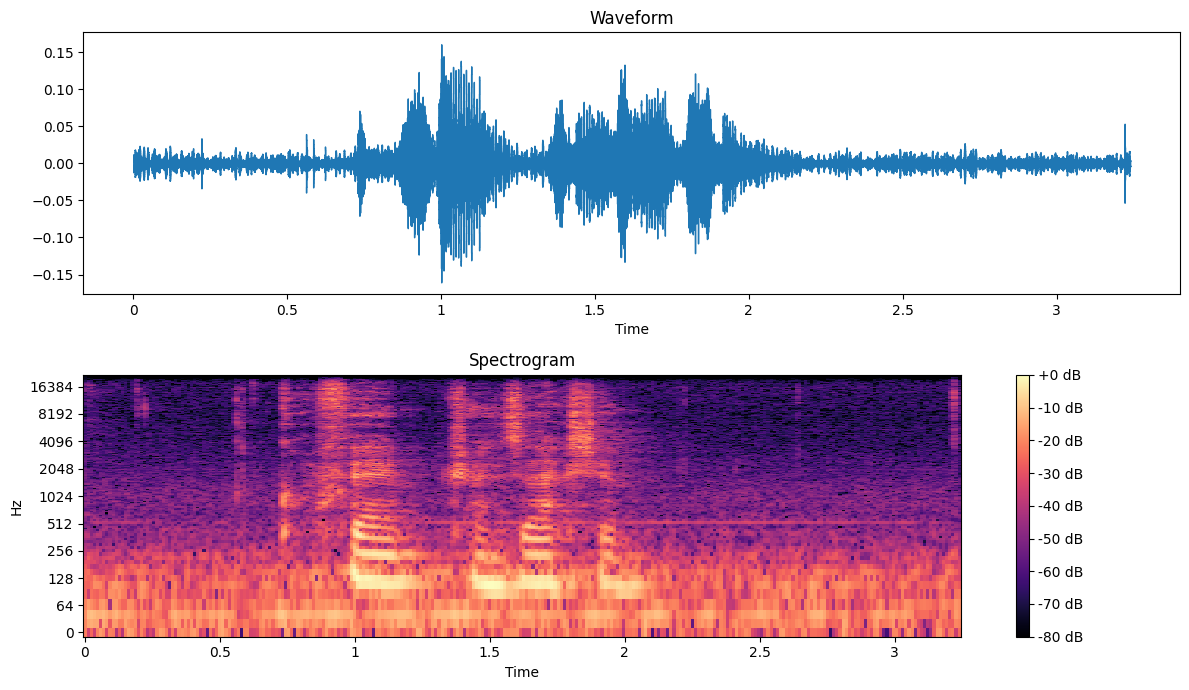

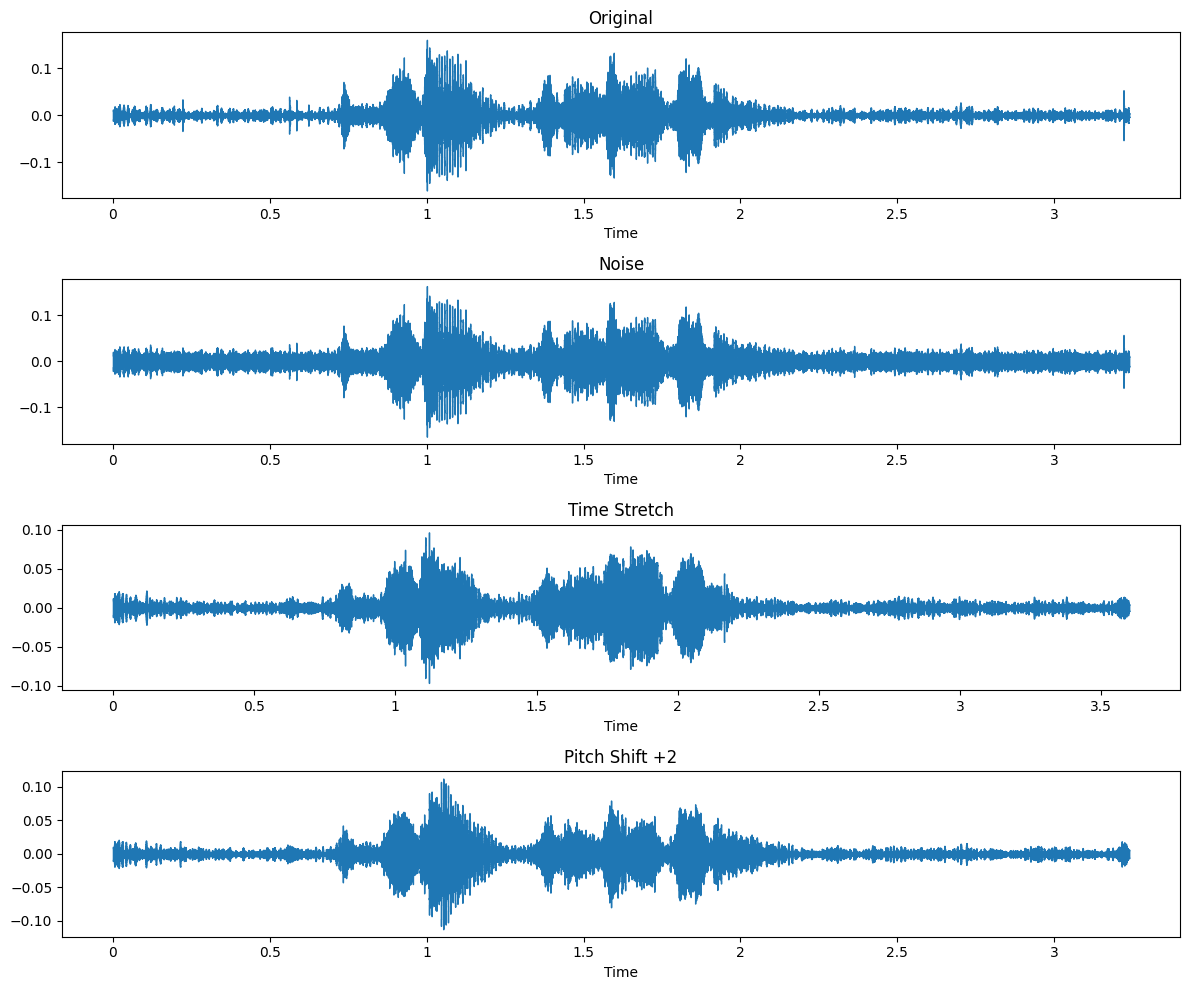

Interpretation: Waveform and spectrogram confirm signal quality; augmentation views show controlled variability that strengthens voice model generalization.


In [35]:
audio_paths = sorted([p for p in AUDIO.rglob("*") if p.suffix.lower() in {".wav", ".mp3", ".flac", ".ogg"}])
print("Total audio files:", len(audio_paths))

if audio_paths:
    y, sr = librosa.load(audio_paths[0], sr=None)

    # A) Waveform + spectrogram
    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title("Waveform")

    S = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(S, sr=sr, x_axis="time", y_axis="log", ax=axes[1])
    axes[1].set_title("Spectrogram")
    fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
    plt.tight_layout()
    plt.show()

    # B) Augmentation panel
    y_noise = y + 0.005 * np.random.randn(len(y)).astype(np.float32)
    y_stretch = librosa.effects.time_stretch(y.astype(np.float32), rate=0.9)
    y_pitch = librosa.effects.pitch_shift(y.astype(np.float32), sr=sr, n_steps=2)

    fig, axes = plt.subplots(4, 1, figsize=(12, 10))
    librosa.display.waveshow(y, sr=sr, ax=axes[0]); axes[0].set_title("Original")
    librosa.display.waveshow(y_noise, sr=sr, ax=axes[1]); axes[1].set_title("Noise")
    librosa.display.waveshow(y_stretch, sr=sr, ax=axes[2]); axes[2].set_title("Time Stretch")
    librosa.display.waveshow(y_pitch, sr=sr, ax=axes[3]); axes[3].set_title("Pitch Shift +2")
    plt.tight_layout()
    plt.show()

print("Interpretation: Waveform and spectrogram confirm signal quality; augmentation views show controlled variability that strengthens voice model generalization.")

## 12) Run Audio Feature Extraction

audio_features.csv shape: (28, 72)


,member_id,source_path,augmentation,mfcc_1_mean,mfcc_1_std,mfcc_1_min,mfcc_1_max,mfcc_2_mean,mfcc_2_std,mfcc_2_min,...,centroid_max,zcr_mean,zcr_std,zcr_min,zcr_max,rms_mean,rms_std,rms_min,rms_max,duration_sec
0,member_1,/content/ML_Multimodal-User-Auth-System/data/a...,original,-395.779205,59.797188,-463.351562,-46.015488,55.493992,30.318687,-49.951332,...,9218.752548,0.040757,0.064488,0.000000,0.309570,0.091086,0.206498,0.003998,0.999969,3.343673
1,member_1,/content/ML_Multimodal-User-Auth-System/data/a...,noise,-314.819855,37.006603,-370.093140,-45.380138,26.785545,23.299236,-46.609047,...,10680.542957,0.154190,0.137032,0.000000,0.390625,0.092012,0.206139,0.006122,1.000198,3.343673
2,member_1,/content/ML_Multimodal-User-Auth-System/data/a...,stretch,-408.798340,51.532406,-456.800201,-46.439419,43.418194,28.138245,-50.205544,...,9485.532547,0.037989,0.060502,0.000000,0.322266,0.080187,0.190350,0.002242,0.997714,3.715193
3,member_1,/content/ML_Multimodal-User-Auth-System/data/a...,pitch+2,-408.773895,50.603931,-456.657257,-49.583878,42.545055,28.021456,-59.889851,...,10764.947575,0.046679,0.078190,0.000000,0.415039,0.079339,0.190128,0.002108,0.987541,3.343673
4,member_1,/content/ML_Multimodal-User-Auth-System/data/a...,original,-411.839844,90.947563,-498.034668,-216.696457,90.943581,31.835379,-31.174389,...,10480.697000,0.070654,0.084229,0.009277,0.455078,0.014012,0.011151,0.003485,0.051832,3.239184


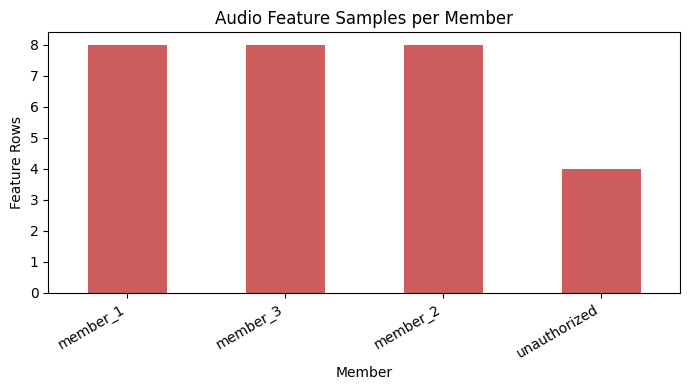

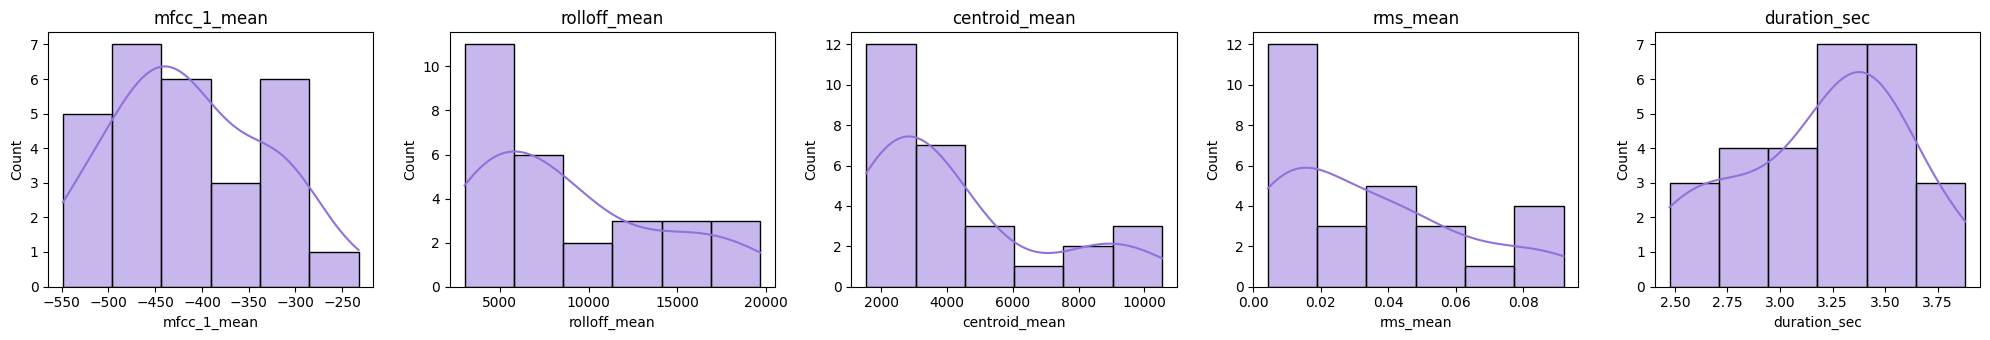

Interpretation: Audio feature coverage across members and stable feature distributions support reliable voice model training.


In [36]:
subprocess.run([sys.executable, "-m", "src.audio_pipeline"], check=True)
aud_features = pd.read_csv(PROCESSED / "audio_features.csv")
print("audio_features.csv shape:", aud_features.shape)
display(aud_features.head())

# Integrated diagnostics for audio feature coverage and distribution
if "member_id" in aud_features.columns:
    plt.figure(figsize=(7, 4))
    aud_features["member_id"].value_counts().plot(kind="bar", color="indianred")
    plt.title("Audio Feature Samples per Member")
    plt.xlabel("Member")
    plt.ylabel("Feature Rows")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

candidate_cols = ["mfcc_1_mean", "rolloff_mean", "centroid_mean", "rms_mean", "duration_sec"]
plot_cols = [c for c in candidate_cols if c in aud_features.columns]
if plot_cols:
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(4 * len(plot_cols), 3.5))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        sns.histplot(aud_features[col], kde=True, ax=ax, color="mediumpurple")
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

print("Interpretation: Audio feature coverage across members and stable feature distributions support reliable voice model training.")

## 13) Train Face, Voice, and Product Models

In [37]:
subprocess.run([sys.executable, "-m", "src.train_models"], check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'src.train_models'], returncode=0)

## 14) Display Evaluation Metrics

In [38]:
with open(REPORTS / "metrics.json", "r", encoding="utf-8") as f:
    metrics = json.load(f)

print(json.dumps(metrics, indent=2))
rows = []
for model_name, vals in metrics.items():
    rows.append({
        "model": model_name,
        "accuracy": vals.get("accuracy"),
        "f1_weighted": vals.get("f1_weighted"),
        "loss": vals.get("loss")
    })
display(pd.DataFrame(rows))

{
  "facial_recognition": {
    "accuracy": 0.875,
    "f1_weighted": 0.825,
    "loss": 0.3948978876253383
  },
  "voice_verification": {
    "accuracy": 0.8333333333333334,
    "f1_weighted": 0.7666666666666666,
    "loss": 0.3950451571972274
  },
  "product_recommendation": {
    "accuracy": 0.7954545454545454,
    "f1_weighted": 0.7878440513734631,
    "loss": 0.7998468066806727
  }
}


,model,accuracy,f1_weighted,loss
0,facial_recognition,0.875000,0.825000,0.394898
1,voice_verification,0.833333,0.766667,0.395045
2,product_recommendation,0.795455,0.787844,0.799847


## 15) System Demo: Authorized and Unauthorized

In [39]:
subprocess.run([
    sys.executable, "-m", "src.auth_system_cli",
    "--face-image", "data/images/member_1/neutral.jpg",
    "--voice-audio", "data/audio/member_1/yes_approve.wav"
], check=True)

subprocess.run([
    sys.executable, "-m", "src.auth_system_cli",
    "--face-image", "data/images/unauthorized/unauthorized.jpg",
    "--voice-audio", "data/audio/unauthorized/unauthorized voice.wav"
], check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'src.auth_system_cli', '--face-image', 'data/images/unauthorized/unauthorized.jpg', '--voice-audio', 'data/audio/unauthorized/unauthorized voice.wav'], returncode=0)